# TechTrack use case 

# Task 3: Threshold design
## Selecting the best NMS IoU threshold for Model 2

The goal of this notebook is to choose and justify the best Non-Maximum Suppression IoU threshold (`nms_iou_threshold`) used in `modules/inference/nms.py`.

- A **lower** IoU threshold is more aggressive: it removes more overlapping boxes → fewer duplicates, but can suppress valid nearby objects.
- A **higher** IoU threshold is less aggressive: it keeps more boxes → better recall in crowded scenes, but increases duplicate detections (false positives).

We sweep `nms_iou_threshold` over a grid and evaluate on the sampled subset of Task 2:
- overall **mAP** (11-point interpolation, via your `metrics.py`)
- per-class AP
- FP/FN counts (confusion-style breakdown) to understand precision/recall trade-offs

We then pick a threshold that maximizes mAP.

In [7]:

# Imports
import os, glob, time, pickle
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **k: x

import sys
from pathlib import Path

TECHTRACK_DIR = Path.cwd().parent / "techtrack"
sys.path.insert(0, str(TECHTRACK_DIR))

from modules.inference.model import Detector
from modules.inference.nms import NMS
from modules.utils import metrics


## 1) Paths and configuration

In [9]:
import os

REPO_ROOT = os.getcwd()

# Use the sampled subset folder
# (images + labels in SAME folder)
SAMPLED_SUBSET_DIR = os.path.join(REPO_ROOT, "analysis_cache_sampling", "sampled_subset")

DATASET_DIR = SAMPLED_SUBSET_DIR
assert os.path.isdir(DATASET_DIR), f"Sampled subset dir missing: {DATASET_DIR}"

# Model paths (unchanged)
MODELS_DIR = os.path.join(TECHTRACK_DIR, "storage", "yolo_models")

MODEL2_CFG = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_2.cfg")
MODEL2_WEIGHTS = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_2.weights")

# Names file: prefer the sampled subset dir
CLASS_NAMES_PATH = os.path.join(DATASET_DIR, "logistics.names")

assert os.path.exists(MODEL2_CFG) and os.path.exists(MODEL2_WEIGHTS), "Model 2 cfg/weights missing"
assert os.path.exists(CLASS_NAMES_PATH), f"logistics.names missing at {CLASS_NAMES_PATH}"
assert os.path.isdir(MODELS_DIR), "Models dir missing"

with open(CLASS_NAMES_PATH, "r") as f:
    CLASS_NAMES = [ln.strip() for ln in f if ln.strip()]
NUM_CLASSES = len(CLASS_NAMES)

# Fixed evaluation settings
SCORE_THRESHOLD = 0.5
MAP_IOU_THRESHOLD = 0.5
EVAL_TYPE = "class_scores"

# NMS sweep grid
NMS_GRID = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

# Cache results for this sweep (separate cache)
CACHE_DIR = os.path.join(REPO_ROOT, "cache_nms_sweep_subset")
os.makedirs(CACHE_DIR, exist_ok=True)

print("DATASET_DIR (subset):", DATASET_DIR)
print("MODELS_DIR          :", MODELS_DIR)
print("NUM_CLASSES         :", NUM_CLASSES)
print("CACHE_DIR           :", CACHE_DIR)

DATASET_DIR (subset): C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\analysis\analysis_cache_sampling\sampled_subset
MODELS_DIR          : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\yolo_models
NUM_CLASSES         : 20
CACHE_DIR           : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\analysis\cache_nms_sweep_subset


## 2) Dataset utilities

In [5]:
from typing import List, Tuple
import glob
import os

def list_dataset_pairs(dataset_dir: str) -> List[Tuple[str, str]]:
    imgs = sorted(glob.glob(os.path.join(dataset_dir, "*.jpg")) + glob.glob(os.path.join(dataset_dir, "*.png")))
    lbls = sorted(glob.glob(os.path.join(dataset_dir, "*.txt")))
    lbl_map = {os.path.splitext(os.path.basename(p))[0]: p for p in lbls}
    pairs = []
    for img in imgs:
        stem = os.path.splitext(os.path.basename(img))[0]
        if stem in lbl_map:
            pairs.append((img, lbl_map[stem]))
    return pairs

def parse_yolo_label_file(label_path: str, img_w: int, img_h: int):
    boxes, classes = [], []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            
            if 0.0 <= xc <= 1.5 and 0.0 <= yc <= 1.5 and 0.0 <= w <= 1.5 and 0.0 <= h <= 1.5:
                xc *= img_w; yc *= img_h; w *= img_w; h *= img_h
            x = int(xc - w/2.0); y = int(yc - h/2.0)
            boxes.append([x, y, int(w), int(h)])
            classes.append(cid)
    return boxes, classes

pairs = list_dataset_pairs(DATASET_DIR)
print("Pairs:", len(pairs))


Pairs: 5000


## 3) Evaluation helpers
We compute mAP via the `metrics.match_detections` and `calculate_precision_recall_curve` functions defined in our modules, plus 11-pt interpolation.
We also compute FP/FN counts to understand precision/recall tradeoffs.

In [4]:

def ap_11_point(recall_points, precision_points):
    """
    Compute Average Precision using the 11-point interpolation method.

    The 11-point AP averages precision values at 11 equally spaced recall levels
    (0.0, 0.1, 0.2, ..., 1.0). For each recall threshold, the maximum precision
    among all recall values greater than or equal to that threshold is taken.
    If no such precision exists, the value is 0.0.

    Args:
        recall_points (list of float): Recall values at each detection threshold.
        precision_points (list of float): Corresponding precision values.

    Returns:
        float: 11-point interpolated Average Precision.
    """
    if len(recall_points) == 0 or len(precision_points) == 0:
        return 0.0

    # Zip recall and precision for easier processing
    pts = list(zip(recall_points, precision_points))
    vals = []

    # Iterate over 11 recall levels from 0.0 to 1.0 in steps of 0.1
    for r_th in [i/10.0 for i in range(11)]:
        # Find all precision values where recall >= current threshold
        cand = [p for r, p in pts if r >= r_th]
        # Take the maximum precision, or 0.0 if none
        vals.append(max(cand) if cand else 0.0)
    return float(np.mean(vals))

def compute_map_and_ap(y_true, pred_scores, num_classes: int):
    """
    Compute mean Average Precision (mAP) and per-class Average Precision (AP).

    This function uses a utility to compute precision-recall curves for each class,
    then applies 11-point interpolation to derive AP per class.

    Args:
        y_true (list or np.ndarray): Ground truth labels (one-hot or class indices).
        pred_scores (list or np.ndarray): Predicted confidence scores per class.
        num_classes (int): Total number of classes.

    Returns:
        tuple: (map_value, ap_per_class)
            - map_value (float): Mean of AP over all classes.
            - ap_per_class (np.ndarray): Array of shape (num_classes,) with AP for each class.
    """
    precision, recall, thresholds = metrics.calculate_precision_recall_curve(
        y_true, pred_scores, num_classes=num_classes
    )
    ap = np.zeros((num_classes,), dtype=float)
    for c in range(num_classes):
        ap[c] = ap_11_point(recall[c], precision[c])
    return float(ap.mean()), ap

# Confusion-style FP/FN counts (matched by score-desc greedy; ground truth matched at most once)
def iou_xywh(a, b) -> float:
    """
    Compute Intersection over Union (IoU) for two bounding boxes in XYWH format.

    Boxes are given as [x, y, width, height] where (x, y) is the top‑left corner.
    The function calculates overlap area divided by union area.

    Args:
        a (list or tuple of 4 numbers): First bounding box.
        b (list or tuple of 4 numbers): Second bounding box.

    Returns:
        float: IoU in [0.0, 1.0]; 0.0 if union is zero.
    """
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ax1, ay1, ax2, ay2 = float(ax), float(ay), float(ax+aw), float(ay+ah)
    bx1, by1, bx2, by2 = float(bx), float(by), float(bx+bw), float(by+bh)
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw*ih
    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = area_a + area_b - inter
    return inter/union if union > 0 else 0.0

def fp_fn_counts_per_dataset(pred_boxes, pred_classes, pred_scores, gt_boxes, gt_classes, iou_thr=0.5):
    """
    Count false positives and false negatives per class across the entire dataset.

    For each image, detections are sorted by score (descending) and greedily matched
    to ground truth boxes. A detection is considered a true positive if it matches
    an unmatched ground truth with IoU >= iou_thr. Unmatched detections become false
    positives (FP) for the predicted class. Unmatched ground truths become false
    negatives (FN) for the true class.

    Args:
        pred_boxes (list of lists): Per-image predicted boxes in XYWH format.
        pred_classes (list of lists): Per-image predicted class IDs.
        pred_scores (list of lists): Per-image predicted confidence scores.
        gt_boxes (list of lists): Per-image ground truth boxes.
        gt_classes (list of lists): Per-image ground truth class IDs.
        iou_thr (float, optional): IoU threshold for considering a match. Default 0.5.

    Returns:
        tuple: (fp, fn)
            - fp (np.ndarray): False positives per class, shape (NUM_CLASSES,).
            - fn (np.ndarray): False negatives per class, shape (NUM_CLASSES,).

    """
    # Initialize per-class counters
    fp = np.zeros((NUM_CLASSES,), dtype=int)
    fn = np.zeros((NUM_CLASSES,), dtype=int)

    # Iterate over each image
    for i in range(len(gt_boxes)):
        # Get predictions for this image
        det_boxes = pred_boxes[i]
        det_cls = pred_classes[i]
        det_sc = pred_scores[i]

        # Sort detections by descending score to prioritize high-confidence matches
        order = np.argsort(np.asarray(det_sc, dtype=float))[::-1] if len(det_sc) else []
        det_boxes = [det_boxes[j] for j in order] if len(det_boxes) else []
        det_cls = [det_cls[j] for j in order] if len(det_cls) else []

        # Keep track of which ground truth boxes have been matched
        matched_gt = set()

        # Detections -> match or FP
        for d in range(len(det_boxes)):
            best_g = -1
            best_iou = 0.0

            # Find the best matching ground truth that is not already matched
            for g in range(len(gt_boxes[i])):
                if g in matched_gt:
                    continue
                iou = iou_xywh(det_boxes[d], gt_boxes[i][g])
                if iou > best_iou:
                    best_iou = iou
                    best_g = g

            # If a match is found with IoU >= threshold, consider it a true positive
            if best_g != -1 and best_iou >= iou_thr:
                matched_gt.add(best_g)
            else:
                c = int(det_cls[d])
                if 0 <= c < NUM_CLASSES:
                    fp[c] += 1

        # Ground truth not matched -> FN
        for g in range(len(gt_boxes[i])):
            if g not in matched_gt:
                c = int(gt_classes[i][g])
                if 0 <= c < NUM_CLASSES:
                    fn[c] += 1

    return fp, fn


## 4) Run NMS sweep on Model 2 (with caching)

For each `nms_iou_threshold` value, we:

1) Run `predict → post_process` once per image
2) Apply NMS with the tested IoU threshold
3) Compute mAP + per-class AP + FP/FN

Results are cached for eventual rerunning.

In [9]:

@dataclass
class SweepResult:
    """
    Stores results of a single NMS IoU threshold evaluation.

    Attributes:
        nms_iou (float): The NMS IoU threshold used.
        map_value (float): Mean Average Precision (mAP) over all classes.
        ap_per_class (np.ndarray): Array of AP per class, shape (NUM_CLASSES,).
        fp_per_class (np.ndarray): False positives per class.
        fn_per_class (np.ndarray): False negatives per class.
        mean_dets_per_img (float): Average number of detections per image after NMS.
        latency_ms_per_img (float): Average inference + post-processing time per image (ms).
    """
    nms_iou: float
    map_value: float
    ap_per_class: np.ndarray
    fp_per_class: np.ndarray
    fn_per_class: np.ndarray
    mean_dets_per_img: float
    latency_ms_per_img: float

def evaluate_for_nms_iou(nms_iou: float, force: bool = False) -> SweepResult:
    """
    Evaluate the model (MODEL2) on the dataset for a specific NMS IoU threshold.

    Runs detection with the given NMS setting, computes mAP, false positives/negatives,
    latency, and average detections per image. Caches results to avoid recomputation.

    Args:
        nms_iou (float): The NMS IoU threshold to evaluate.
        force (bool, optional): If True, ignore cached results and recompute.

    Returns:
        SweepResult: Aggregated metrics for this NMS threshold.
    """
    # Define cache file path based on NMS threshold
    cache_path = os.path.join(CACHE_DIR, f"model2_nms_{nms_iou:.2f}.pkl")
    # Load from cache if exists and not forced
    if (not force) and os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    # Initialize detector and NMS with the given threshold
    detector = Detector(MODEL2_WEIGHTS, MODEL2_CFG, CLASS_NAMES_PATH, score_threshold=SCORE_THRESHOLD)
    nms = NMS(score_threshold=SCORE_THRESHOLD, nms_iou_threshold=float(nms_iou))

    # Containers for per-image ground truth and predictions
    image_files = []
    gt_boxes_all, gt_classes_all = [], []
    pred_boxes_all, pred_classes_all, pred_scores_all, pred_cls_scores_all = [], [], [], []

    # Performance tracking
    t0 = time.perf_counter()
    det_counts = []

    # Loop over all image-label pairs (global variable 'pairs')
    for img_path, lbl_path in tqdm(pairs, desc=f"NMS={nms_iou:.2f}", total=len(pairs)):
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]

        # Parse ground truth boxes and classes from YOLO label file
        gt_b, gt_c = parse_yolo_label_file(lbl_path, W, H)

        # Run detector and post-process raw outputs
        raw = detector.predict(img)
        
        # Apply NMS to filter redundant detections
        bboxes, class_ids, scores, class_scores = detector.post_process(raw)
        bboxes, class_ids, scores, class_scores = nms.filter(bboxes, class_ids, scores, class_scores)

        # Ensure class_scores is a 2D array (num_det, NUM_CLASSES)
        if len(class_scores) == 0:
            cls_arr = np.zeros((0, NUM_CLASSES), dtype=float)
        else:
            cls_arr = np.asarray(class_scores, dtype=float)
            if cls_arr.ndim == 1:
                cls_arr = cls_arr.reshape(1, -1)
            if cls_arr.shape[1] != NUM_CLASSES:
                tmp = np.zeros((cls_arr.shape[0], NUM_CLASSES), dtype=float)
                m = min(NUM_CLASSES, cls_arr.shape[1])
                tmp[:, :m] = cls_arr[:, :m]
                cls_arr = tmp

        # Store results for this image
        image_files.append(img_path)
        gt_boxes_all.append(gt_b)
        gt_classes_all.append(gt_c)
        pred_boxes_all.append(bboxes)
        pred_classes_all.append(class_ids)
        pred_scores_all.append([float(s) for s in scores])
        pred_cls_scores_all.append(cls_arr)

        det_counts.append(len(bboxes))

    # Compute latency and average detections
    t1 = time.perf_counter()
    latency_ms = 1000.0 * (t1 - t0) / max(1, len(image_files))
    mean_dets = float(np.mean(det_counts)) if det_counts else 0.0

    # mAP
    y_true, pred_scores = metrics.match_detections(
        pred_boxes_all, pred_classes_all, pred_scores_all, pred_cls_scores_all,
        gt_boxes_all, gt_classes_all,
        map_iou_threshold=MAP_IOU_THRESHOLD,
        eval_type=EVAL_TYPE
    )
    map_value, ap_per_class = compute_map_and_ap(y_true, pred_scores, NUM_CLASSES)

    # Compute per-class false positives and false negatives
    fp, fn = fp_fn_counts_per_dataset(
        pred_boxes_all, pred_classes_all, pred_scores_all, gt_boxes_all, gt_classes_all,
        iou_thr=MAP_IOU_THRESHOLD
    )

    result = SweepResult(
        nms_iou=float(nms_iou),
        map_value=float(map_value),
        ap_per_class=ap_per_class,
        fp_per_class=fp,
        fn_per_class=fn,
        mean_dets_per_img=mean_dets,
        latency_ms_per_img=float(latency_ms),
    )

    with open(cache_path, "wb") as f:
        pickle.dump(result, f)
    return result

FORCE = False  # seSt True to recompute sweep
sweep = [evaluate_for_nms_iou(v, force=FORCE) for v in NMS_GRID]

# Summarize
rows = []
for r in sweep:
    rows.append({
        "nms_iou_threshold": r.nms_iou,
        "mAP": r.map_value,
        "mean_dets_per_img": r.mean_dets_per_img,
        "latency_ms_per_img": r.latency_ms_per_img,
        "FP_total": int(r.fp_per_class.sum()),
        "FN_total": int(r.fn_per_class.sum()),
    })
sweep_df = pd.DataFrame(rows).sort_values("nms_iou_threshold")
display(sweep_df)


NMS=0.60: 100%|████████████████████████████████████████████████████████████████████| 5000/5000 [06:52<00:00, 12.12it/s]


,nms_iou_threshold,mAP,mean_dets_per_img,latency_ms_per_img,FP_total,FN_total
0,0.30,0.521710,1.7576,149.297911,1561,7713
1,0.35,0.521909,1.7686,85.317603,1579,7676
2,0.40,0.528925,1.7782,76.293867,1594,7643
3,0.45,0.529020,1.7912,87.201063,1618,7602
4,0.50,0.529018,1.8026,309.209374,1642,7569
5,0.55,0.528293,1.8244,86.768646,1718,7536
6,0.60,0.526584,1.8490,82.515938,1823,7518


## 5) Pick the best threshold

**Decision rule:** We choose the `nms_iou_threshold` that yields the highest mAP. If multiple thresholds have similar mAP, prefer the one with **lower FP_total** (cleaner output) or lower latency.


In [10]:

best_by_map = sweep_df.loc[sweep_df["mAP"].idxmax()]
best_thr = float(best_by_map["nms_iou_threshold"])
print("Best by mAP:", dict(best_by_map))

# Also show top-3 by mAP
display(sweep_df.sort_values("mAP", ascending=False).head(3))


Best by mAP: {'nms_iou_threshold': np.float64(0.45), 'mAP': np.float64(0.5290195241299781), 'mean_dets_per_img': np.float64(1.7912), 'latency_ms_per_img': np.float64(87.20106267998926), 'FP_total': np.float64(1618.0), 'FN_total': np.float64(7602.0)}


,nms_iou_threshold,mAP,mean_dets_per_img,latency_ms_per_img,FP_total,FN_total
3,0.45,0.529020,1.7912,87.201063,1618,7602
4,0.50,0.529018,1.8026,309.209374,1642,7569
2,0.40,0.528925,1.7782,76.293867,1594,7643


## 6) Visualize the trade-offs

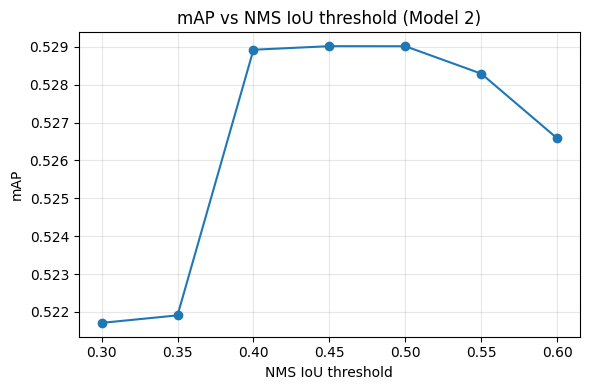

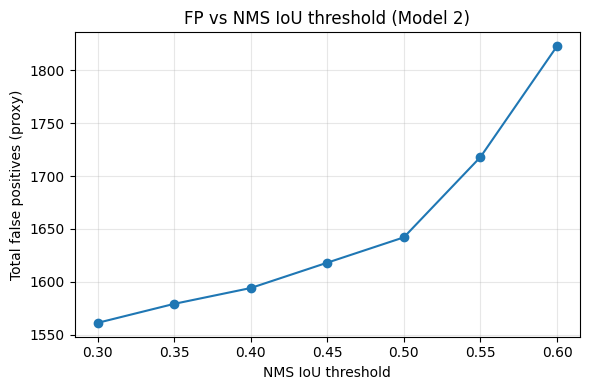

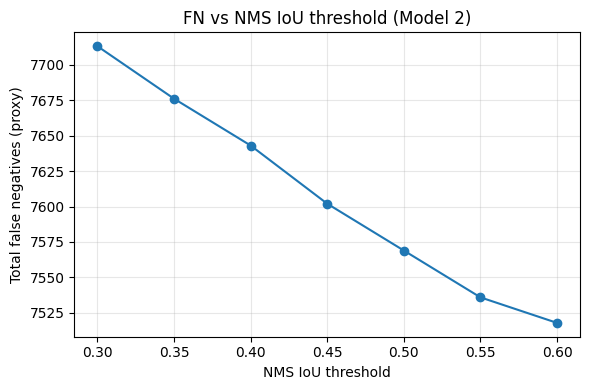

In [11]:

plt.figure(figsize=(6,4))
plt.plot(sweep_df["nms_iou_threshold"], sweep_df["mAP"], marker="o")
plt.xlabel("NMS IoU threshold")
plt.ylabel("mAP")
plt.title("mAP vs NMS IoU threshold (Model 2)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(sweep_df["nms_iou_threshold"], sweep_df["FP_total"], marker="o")
plt.xlabel("NMS IoU threshold")
plt.ylabel("Total false positives (proxy)")
plt.title("FP vs NMS IoU threshold (Model 2)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(sweep_df["nms_iou_threshold"], sweep_df["FN_total"], marker="o")
plt.xlabel("NMS IoU threshold")
plt.ylabel("Total false negatives (proxy)")
plt.title("FN vs NMS IoU threshold (Model 2)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7) Which classes are most sensitive to NMS threshold?
We compute per-class AP deltas between the best threshold and a baseline (0.40), then list the largest changes.

In [16]:

baseline_thr = 0.40
base = {r.nms_iou: r for r in sweep}.get(baseline_thr, None)
best = {r.nms_iou: r for r in sweep}.get(best_thr, None)

if base is None or best is None:
    print("Baseline or best threshold results missing from sweep.")
else:
    delta = best.ap_per_class - base.ap_per_class
    class_df = pd.DataFrame({
        "class_id": range(NUM_CLASSES),
        "class_name": CLASS_NAMES,
        "AP_baseline": base.ap_per_class,
        "AP_best": best.ap_per_class,
        "delta_AP": delta
    }).sort_values("delta_AP", ascending=False)

    display(class_df.head(20))


,class_id,class_name,AP_baseline,AP_best,delta_AP
8,8,ladder,0.326845,0.328364,0.001519
7,7,helmet,0.459277,0.460300,0.001023
13,13,safety vest,0.527360,0.528080,0.000719
10,10,person,0.502297,0.502574,0.000277
19,19,wood pallet,0.327934,0.328162,0.000228
11,11,qr code,0.752381,0.752377,-0.000004
6,6,gloves,0.640036,0.640031,-0.000005
0,0,barcode,0.613418,0.613411,-0.000007
18,18,van,0.794675,0.794668,-0.000007
9,9,license plate,0.364457,0.364443,-0.000014
